In [3]:
#Import scikit-learn dataset library
from sklearn import datasets

#Load dataset
cancer = datasets.load_breast_cancer()

In [4]:
# print the names of the 13 features
print("Features: ", cancer.feature_names)

# print the label type of cancer('malignant' 'benign')
print("Labels: ", cancer.target_names)

Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Labels:  ['malignant' 'benign']


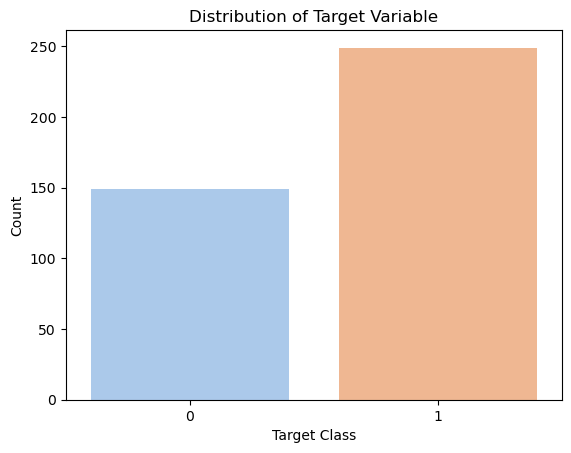

In [18]:
import seaborn as sns
# Visualizing the distribution of the target
sns.countplot(x=y_train, hue=y_train, palette='pastel', legend=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

In [6]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3,random_state=109) # 70% training and 30% test

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define the classifier
rf = RandomForestClassifier(random_state=42)

# Define k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='accuracy')

print(f'Cross-validation accuracy scores: {cv_scores}')
print(f'Mean cross-validation accuracy: {np.mean(cv_scores):.4f}')


Cross-validation accuracy scores: [0.9375     1.         0.9375     0.93670886 0.93670886]
Mean cross-validation accuracy: 0.9497


In [8]:
# Hyperparameter tuning using RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [9]:
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                                   n_iter=10, cv=kfold, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Best parameters
print(f'Best parameters: {random_search.best_params_}')



Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': False}


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Train final model with best parameters
best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_rf.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred))


Test Accuracy: 0.9708
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        63
           1       0.96      1.00      0.98       108

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [22]:
# Evaluate on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = best_rf.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred))



Test Accuracy: 0.9708
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        63
           1       0.96      1.00      0.98       108

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



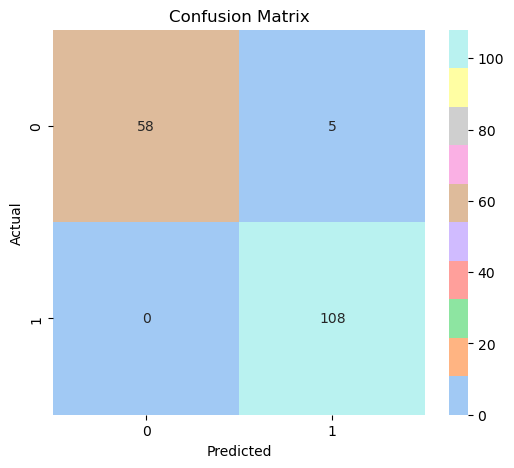

Sensitivity: 1.0000


In [21]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.color_palette("pastel", as_cmap=True), 
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Calculate sensitivity (recall for the positive class)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print(f'Sensitivity: {sensitivity:.4f}')
